# MPhil DIS: S1 Coursework Solution 2025/26

*Nabeel Chaudary*

---
## 1) Plotting Sample Estimates
**10 marks**

### 1(i) plot total sample
- Get hold of your data sample, `sample.csv`, and make a plot of the measured energy, `E`, minus the true energy, `E_0`. This plot should be saved in `figs/Figure1.1.pdf`.

In [1]:
import pandas as pd 

# Load data 
sample_df = pd.read_csv("../sample.csv")
# Take a quick look at the data
sample_df.head()

,E_true,E_rec
0,20,20.116080
1,20,20.910469
2,20,15.256252
3,20,22.628035
4,20,25.062633


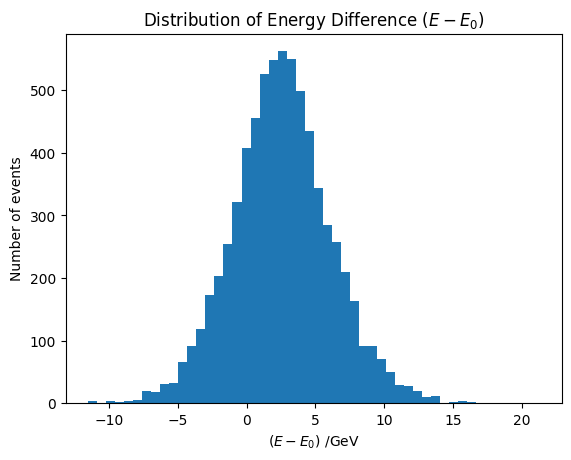

In [2]:
from s1_sol import s1plots

# Calculate the energy difference (used throughout the notebook)
sample_df["E_difference"] = sample_df["E_rec"] - sample_df["E_true"]

# Create Figure 1.1
fig, ax = s1plots.plot1_1(sample_df, bins=50)

### 1(ii) overlay samples at each $E_0$
- Make a plot which shows the distribution of `E - E_0`, with the histograms for each different value of `E_0` overlaid. This plot should be saved in `figs/Figure1.2.pdf`

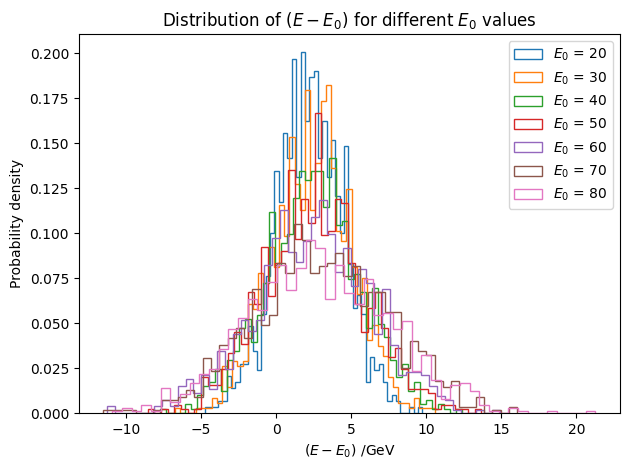

In [3]:
# Create Figure 1.2
fig, ax = s1plots.plot1_2(sample_df, bins=50)

### 1(iii) sample estimates
- Produce sample estimates of the mean, $\hat{\mu}_{\rm samp}$, and standard deviation, $\hat{\sigma}_{\rm samp}$, of $E$ at each value of $E_0$. These should be presented along with sample estimates of the error on these estimates (i.e. the standard error on the mean and the standard error on the standard deviation).
- Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$. This figure should be saved to `figs/Figure1.3.pdf`

In [4]:
from s1_sol import s1funcs

# Calculate the sample estimates for the mean and standard deviation at each E0 value
summary = s1funcs.sample_est(sample_df)

# View the summary dataframe of the results
print(summary)

   E_true     N     mu_est    mu_err  sigma_est  sigma_err
0      20  1000  22.238933  0.070714   2.236165   0.050027
1      30  1000  32.392305  0.083746   2.648283   0.059247
2      40  1000  42.475490  0.099857   3.157760   0.070645
3      50  1000  52.509953  0.105668   3.341508   0.074756
4      60  1000  62.455090  0.122229   3.865221   0.086472
5      70  1000  72.999077  0.139147   4.400211   0.098441
6      80  1000  82.872887  0.148277   4.688922   0.104900


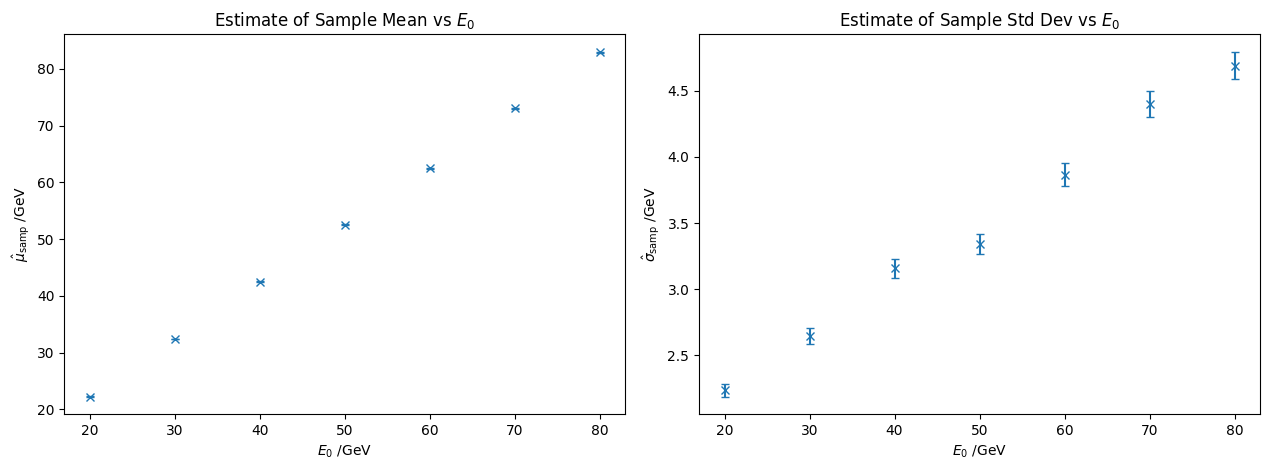

In [5]:
# Create Figure 1.3
fig, ax = s1plots.plot1_3(summary)

### 1(iv) fit trends
- Perform a least squares fit using the energy and width dependence formulas provided in the problem description (at the top of this notebook) to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly into the `results.json` file
- The previously made plots don't have a particular sensible y-scale. Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$ **but this time realign the y-scale** so that you plot $\hat{\mu}_{\rm samp} - E_0$ and $\hat{\sigma}_{\rm samp} / E_0$. You should also **overlay the fitted curves** and add error bands ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure1.4.pdf`

In [6]:
# Perform least-squares fits to the sample estimates to get estimates of the parameters,
# along with their errors 
# and the covariance matrices which will be needed later for bootstrapping
(
    lb_samp,     lb_err_samp,
    dE_samp,     dE_err_samp,
    a_samp,      a_err_samp,
    b_samp,      b_err_samp,
    c_samp,      c_err_samp,
    cov_mu_samp,
    cov_sigma_samp
) = s1funcs.fit_sample_method(summary)

# Print the fit results
print("mean energy fit results:")
print(f"lb = {lb_samp} ± {lb_err_samp}")
print(f"dE  = {dE_samp} ± {dE_err_samp}")

print("\nwidth fit results:")
print(f"a = {a_samp} ± {a_err_samp}")
print(f"b = {b_samp} ± {b_err_samp}")
print(f"c = {c_samp} ± {c_err_samp}")

#make the json file to store results
s1funcs.make_results_json("../results.json")

# Write values into results.json file
s1funcs.update_results_json("sample_ests",
                   lb_samp, lb_err_samp,
                   dE_samp, dE_err_samp,
                   a_samp, a_err_samp,
                   b_samp, b_err_samp,
                   c_samp, c_err_samp)


mean energy fit results:
lb = 1.0104606355125263 ± 0.002003231612863976
dE  = 2.03673408133321 ± 0.08909879066320488

width fit results:
a = 0.33112892819629347 ± 0.0737554469418309
b = 1.4600771767122587 ± 0.3074674164435216
c = 0.04206377432393138 ± 0.00667612985759658
Updated 'sample_ests' in results.json


Limit set for sigma > 0 as sigma must be positive
initial guesses lb=1.0, dE=0.0: as expect detector to be roughly linear so lambda is 1 and unbiased so dE is 0
/n abc>0 negative values are unphysical - starting guesses: a=1.0, b=1.0, c=0.1 -   REASONING

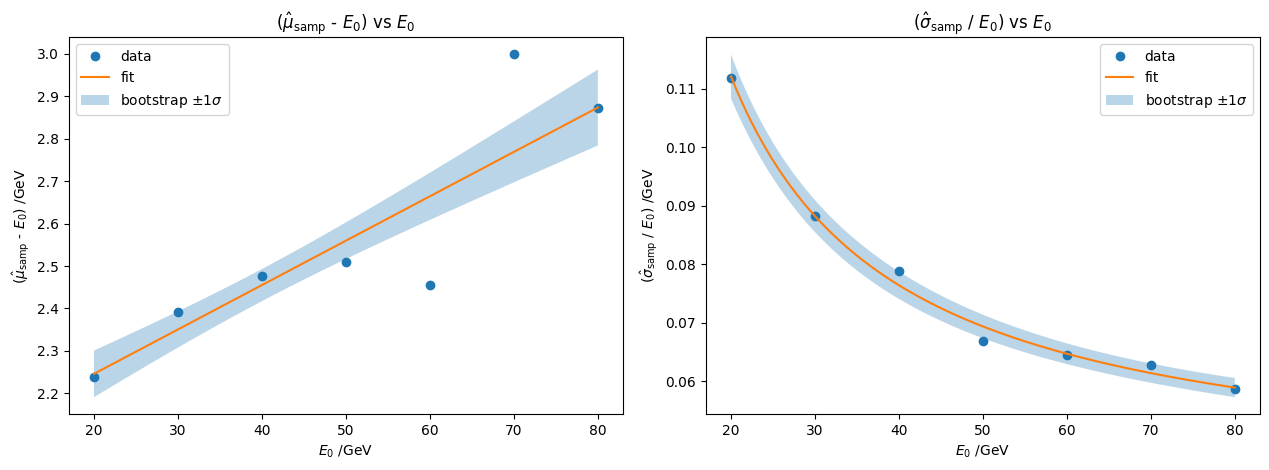

In [7]:
fig, ax = s1plots.plot1_4(
    summary,
    lb_samp, dE_samp,
    a_samp, b_samp, c_samp,
    cov_mu_samp, cov_sigma_samp,
    N_BOOT=1000, random_state=30    #Set bootstrap parameters
)

---
## 2) Individual Fits
**10 marks**

### 2(i) normal fits
- Now instead of sample estimates for the mean and width, perform and unbinned maximum likelihood fit of the distribution of $E$ at each value of $E_0$ using a normal distribution to determine the mean, $\hat{\mu}_{\rm indiv}$, and width, $\hat{\sigma}_{\rm indiv}$, (as well as their errors) at each $E_0$
- Make two plots (sub-axes of the same figure). The left should show the distribution of $E-E_0$ (with the distribution at each value of $E_0$ overlaid) also overlaying the result of the normal likelihood fits. The right should show the distribution of $E - E_0$ for all values and then overlay the approproiately normalised sum of sub-distributions. This plot should be saved in `figs/Figure2.1.pdf`

In [8]:

# Get individual ML values for each E0 value
indiv_summary = s1funcs.indiv_MLsummary(sample_df)

print(indiv_summary)

   E_true     mu_est    mu_err  sigma_est  sigma_err
0      20  22.238933  0.070678   2.235046   0.049977
1      30  32.392305  0.083704   2.646958   0.059187
2      40  42.475490  0.099807   3.156180   0.070574
3      50  52.509953  0.105615   3.339837   0.074680
4      60  62.455090  0.122168   3.863288   0.086385
5      70  72.999077  0.139077   4.398011   0.098342
6      80  82.872887  0.148203   4.686577   0.104794


sigma and mu >0 as energies must be positive. Initial guesses are the sample mean and standard deviation of the data

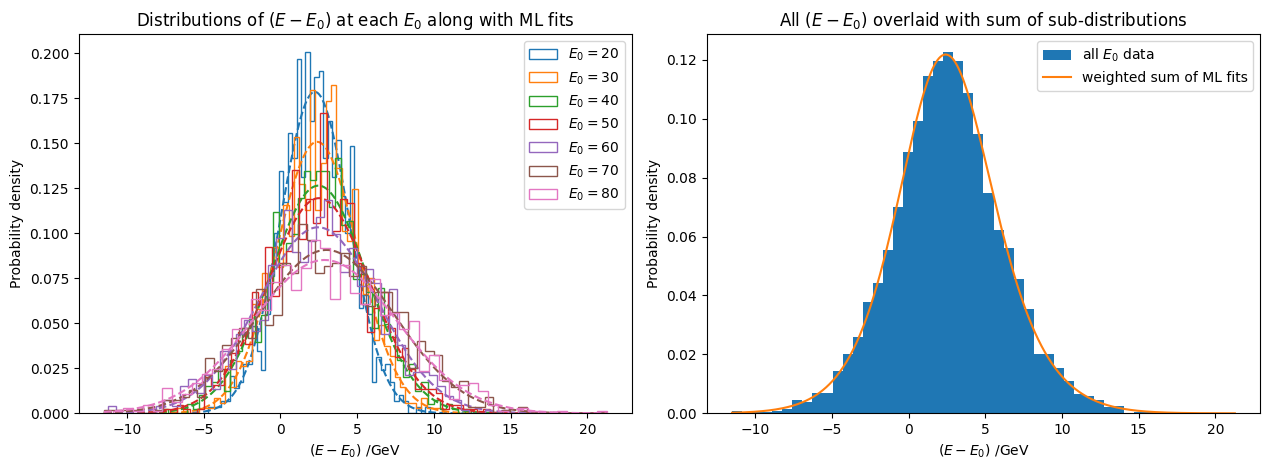

In [9]:
#Create plots
#adjust bins?
fig, ax = s1plots.plot2_1(sample_df, indiv_summary)

### 2(ii) fit trends
- Perform a least squares fit using the energy and width dependence formulas provided in the problem description (at the top of this notebook) to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.
- Make two plots (sub-axes of the same figure) showing the fitted values $\hat{\mu}_{\rm indiv} - E_0$ and $\hat{\sigma}_{\rm indiv}/E_0$ as a function of $E_0$ **as well as** the fitted curves. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure2.2.pdf`

In [10]:
from s1_sol import s1funcs

# Perform least-squares fits to the individual ML estimates to get estimates of the parameters, along with their errors 
# and get the covariance matrices which will be needed later for bootstrapping
(
    lb_indiv,     lb_err_indiv,
    dE_indiv,     dE_err_indiv,
    a_indiv,      a_err_indiv,
    b_indiv,      b_err_indiv,
    c_indiv,      c_err_indiv,
    cov_mu_indiv,
    cov_sigma_indiv
) = s1funcs.fit_sample_method(indiv_summary)

# Print the fit results
print("mean energy fit results:")
print(f"lb = {lb_indiv} ± {lb_err_indiv}")
print(f"dE  = {dE_indiv} ± {dE_err_indiv}")

print("\n width fit results:")
print(f"a = {a_indiv} ± {a_err_indiv}")
print(f"b = {b_indiv} ± {b_err_indiv}")
print(f"c = {c_indiv} ± {c_err_indiv}")

# Write values into results.json file
s1funcs.update_results_json("individual_fits",
                   lb_indiv, lb_err_indiv,
                   dE_indiv, dE_err_indiv,
                   a_indiv, a_err_indiv,
                   b_indiv, b_err_indiv,
                   c_indiv, c_err_indiv)


mean energy fit results:
lb = 1.010460635366825 ± 0.0020022273064661533
dE  = 2.036734088863784 ± 0.08905413643606579

 width fit results:
a = 0.3307253749652801 ± 0.0734492118313903
b = 1.4603968358180852 ± 0.3058008944166386
c = 0.04206370393861847 ± 0.006641306057249885
Updated 'individual_fits' in results.json


Limit set for sigma > 0 as sigma must be positive
initial guesses lb=1.0, dE=0.0: as expect detector to be roughly linear so lambda is 1 and unbiased so dE is 0
/n abc>0 negative values are unphysical - starting guesses: a=1.0, b=1.0, c=0.1 -   REASONING

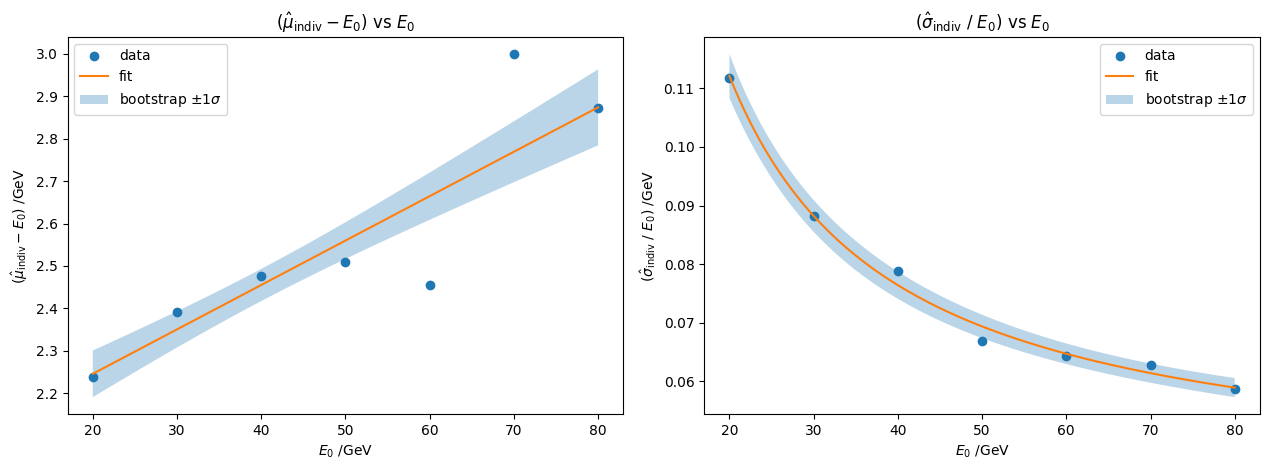

In [11]:
# Create Figure 2.2 
fig, ax = s1plots.plot2_2(
    indiv_summary,
    lb_indiv, dE_indiv,
    a_indiv, b_indiv, c_indiv,
    cov_mu_indiv, cov_sigma_indiv,
    N_BOOT=1000, random_state=30   #Set bootstrap parameters
)

---
## 3.) Simultaneous Fit
**10 marks**

### 3(i) the simultaneous likelihood
- Write down an equation for the simultaneous likelihood in which all points are fitted together, i.e. directly fitting the sample for $\lambda$, $\Delta$, $a$, $b$ and $c$
- Appropriately code this and perform an unbinned maximum likelihood fit to all $E_0$ bins simultaneously, to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.
- Make two plots (sub-axes of the same figure) showing the fitted curves for $\mu_E$ and $\sigma_E$ as a function of $E_0$. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. You should stick to the convention of plotting $\mu_E - E_0$ and $\sigma_E / E_0$ as a function of $E_0$. This figure should be saved to `figs/Figure3.1.pdf`

The simultaneous likelihood is

$$
L(\lambda,\Delta,a,b,c)
=
\prod_{i=1}^{N}
\frac{1}{\sqrt{2\pi}\,\sigma_i}
\exp\left[
-\frac{\big(E_i - (\lambda E_{0,i} + \Delta)\big)^2}{2\sigma_i^2}
\right].
$$

Where the width for event i is

$$
\sigma_i = E_{0,i} \sqrt{
\left(\frac{a}{\sqrt{E_{0,i}}}\right)^2
+ \left(\frac{b}{E_{0,i}}\right)^2
+ c^2 }.
$$


In [12]:
# Perform simultaneous unbinned ML fit to get estimates of the parameters, along with their errors
# and get the covariance matrix which will be needed later for bootstrapping
(
    lb_sim,   lb_err,
    dE_sim, dE_err,
    a_sim,     a_err,
    b_sim,     b_err,
    c_sim,     c_err,
    sim_covariance
) = s1funcs.simultaneous_ML_fit(sample_df)

# Print the fit results
print("Simultaneous unbinned ML fit results")
print(f"lb = {lb_sim} ± {lb_err}")
print(f"dE  = {dE_sim} ± {dE_err}")
print(f"a      = {a_sim} ± {a_err}")
print(f"b      = {b_sim} ± {b_err}")
print(f"c      = {c_sim} ± {c_err}")


# save results in json
s1funcs.update_results_json(
    "simultaneous_fit",
    lb_sim,   lb_err,
    dE_sim, dE_err,
    a_sim,     a_err,
    b_sim,     b_err,
    c_sim,     c_err,
)

Simultaneous unbinned ML fit results
lb = 1.0105481239214882 ± 0.002003941431888201
dE  = 2.0348607572821344 ± 0.08909222354503675
a      = 0.3385806377740752 ± 0.06724174837934771
b      = 1.4277813812855 ± 0.29516832741871135
c      = 0.04153959894318926 ± 0.006293135468269373
Updated 'simultaneous_fit' in results.json


limits lb, a, b, c >0: lamda positive, abc non-negative, dE can be any. initial guesses: lb=1.0,
        dE=0.0,
        a=1.0,
        b=1.0,
        c=0.1, for consistency 

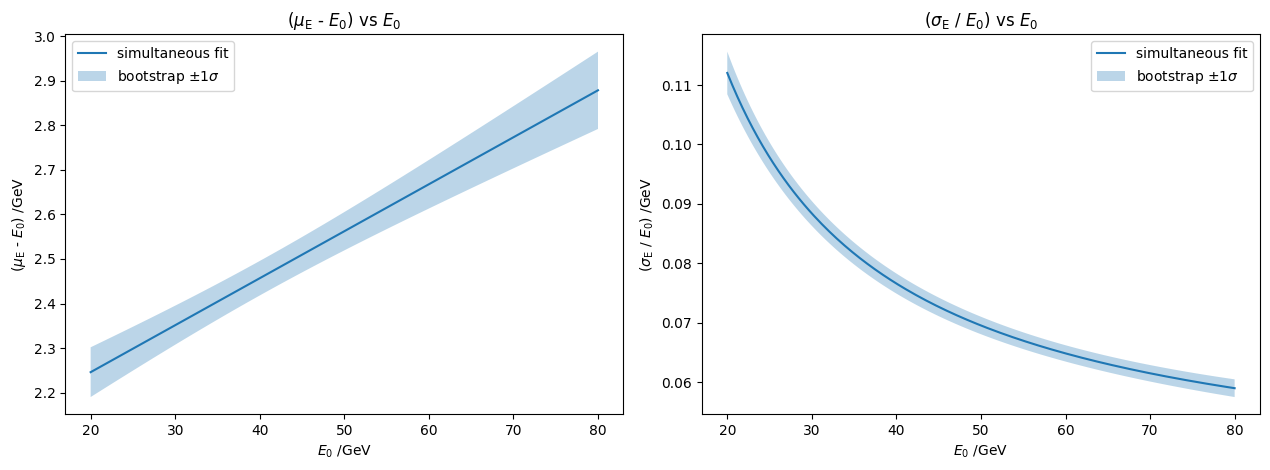

In [13]:
fig, ax = s1plots.plot3_1(
    sample_df,
    lb_sim, dE_sim,
    a_sim, b_sim, c_sim,
    sim_covariance,
    N_BOOT=500, random_state=30
)

### 3(ii) saving the results
- At this point you should have estimates of the five parameters, $\{\lambda, \Delta, a, b, c\}$, (along with their errors), using three different methods: "a sample estimate", "individual fits" and "a simultaneous fit".
- Ensure these are now saved into the `results.json` file in the correct format

In [14]:
# Load and format data in results.json into a table
df_results = s1funcs.load_results_table()
# Print the results table
print(df_results)

          method parameter     value     error
0         sample        lb  1.010461  0.002003
1         sample        dE  2.036734  0.089099
2         sample         a  0.331129  0.073755
3         sample         b  1.460077  0.307467
4         sample         c  0.042064  0.006676
5     individual        lb  1.010461  0.002002
6     individual        dE  2.036734  0.089054
7     individual         a  0.330725  0.073449
8     individual         b  1.460397  0.305801
9     individual         c  0.042064  0.006641
10  simultaneous        lb  1.010548  0.002004
11  simultaneous        dE  2.034861  0.089092
12  simultaneous         a  0.338581  0.067242
13  simultaneous         b  1.427781  0.295168
14  simultaneous         c  0.041540  0.006293


I have saved the results into the results.json file as I went along. So have displayed the results directly taken from the file.

### 3(iii) comparing the results
- Make a plot which shows the estimate and error of each parameter, labelling the different estimation types with different colours.
- The parameters may well have rather different values so you will need to think carefully about how you present this information in a sensible way.
- You should save this in a file called `figs/Figure3.2.pdf`

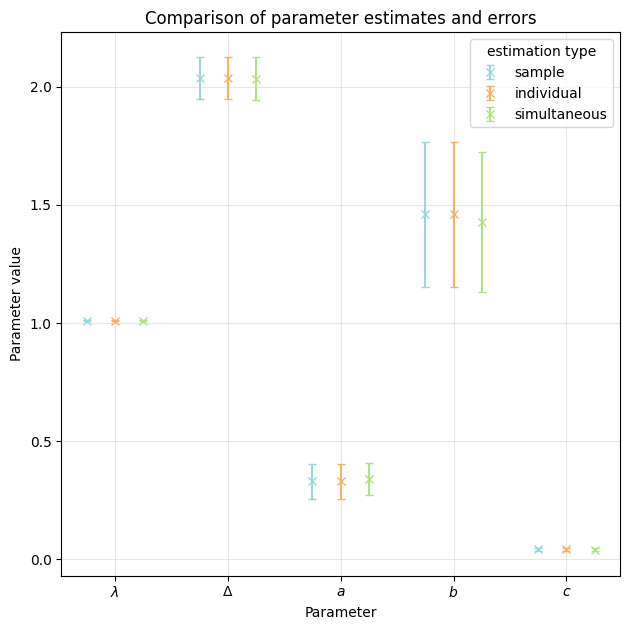

In [15]:
# Create Figure 3.2
fig, ax = s1plots.plot3_2(df_results)


---
## 4.) Bootstrap entire sample
**20 marks**
- Run a non-parameteric bootstrap on the entire analysis using sampling with replacement (and 2500 samples). For reference on my machine this takes ~1 min)
- Produce a figure with 5 subfigures which shows histograms of the bootstrapped values with each method overlaid as a separate colour. You should save this plot in a file called `figs/Figure4.1.pdf`
- Produce a second figure which is the same in style to the plot produced in 3(iii) above this time using the bootstrapped sample to estimate the value and error. You should overlay both sets of points (i.e. the values and errors from parts 1-3 and also the bootstrapped values and errors from part 4). You should save this plot in a file called `figs/Figure4.2.pdf`

In [16]:

boot_df = s1funcs.run_bootstrap_all_methods(
    sample_df, 
    N_BOOT=2500, random_state=30 #Set bootstrap parameters
    )


print(boot_df)


             method parameter     value
0            sample        lb  1.008410
1            sample        lb  1.011246
2            sample        lb  1.009154
3            sample        lb  1.008310
4            sample        lb  1.006911
...             ...       ...       ...
37495  simultaneous         c  0.054339
37496  simultaneous         c  0.049083
37497  simultaneous         c  0.040398
37498  simultaneous         c  0.033053
37499  simultaneous         c  0.024591

[37500 rows x 3 columns]


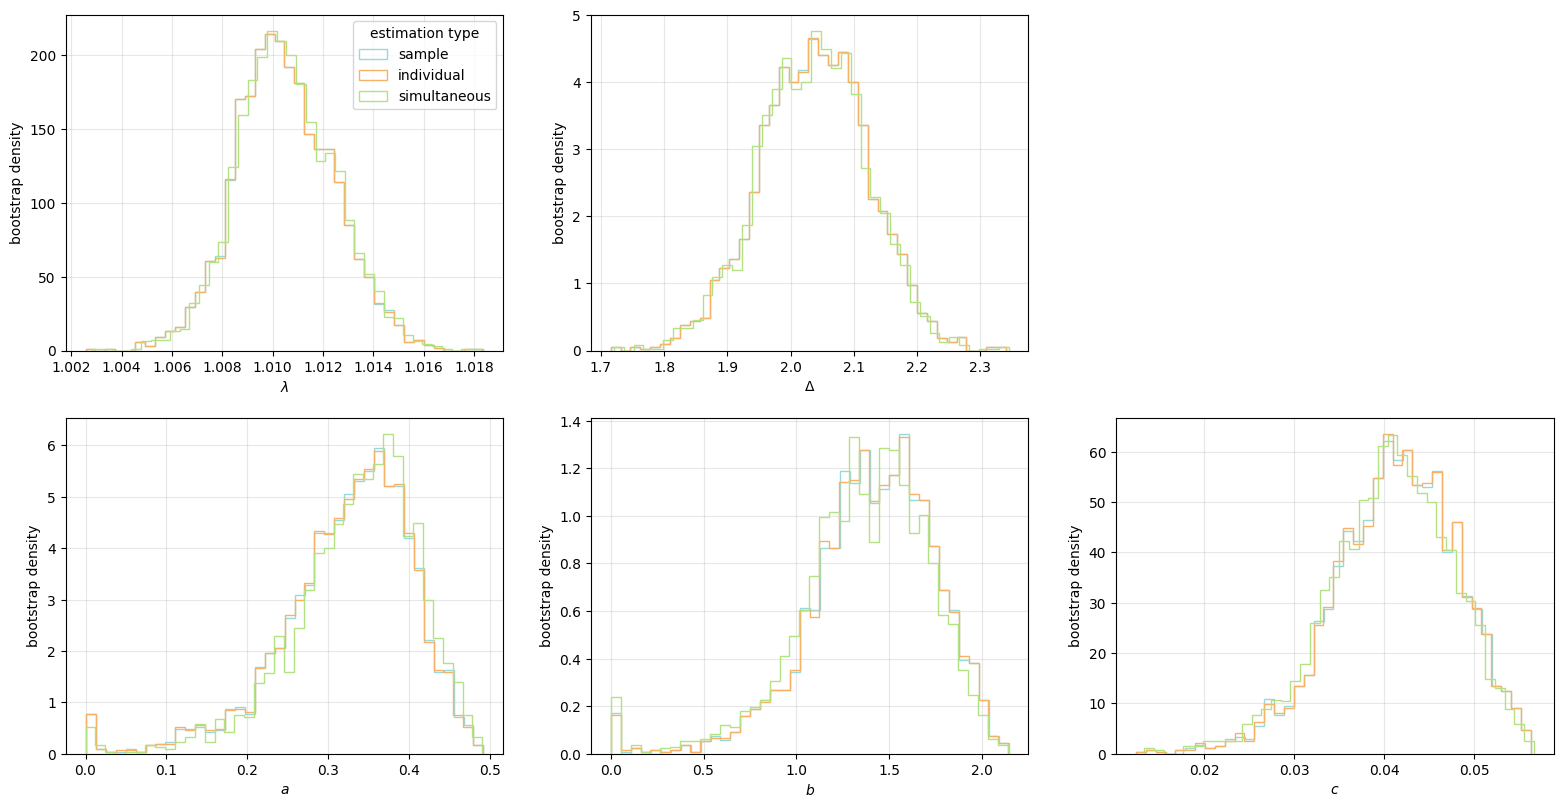

In [17]:
# Create Figure 4.1
fig, ax = s1plots.plot4_1(boot_df)


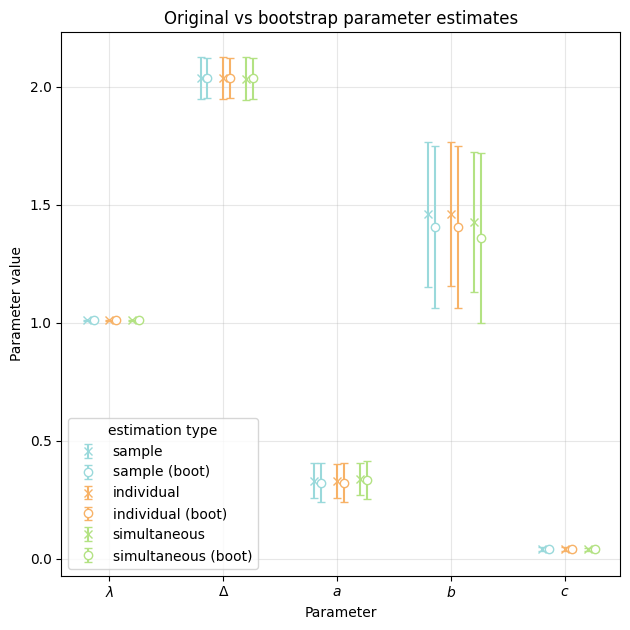

In [18]:
fig, ax = s1plots.plot4_2(boot_df, df_results)


Units differ for each parameter

---
## 5.) Discussion of Results
**20 marks**

- Please briefly discuss your findings in no more than 500 words. Do you find what you would naively expect? Can you comment on any discrepancies you see? Would you redesign the analysis in any way?